In [28]:
import torchvision
import torch
torch.set_printoptions(sci_mode=False, precision=4)

In [29]:
train = torchvision.datasets.MNIST("./data", download=True, train=True, transform=torchvision.transforms.ToTensor())
test = torchvision.datasets.MNIST("./data", download=True, train=False, transform=torchvision.transforms.ToTensor())
train, test

(Dataset MNIST
     Number of datapoints: 60000
     Root location: ./data
     Split: Train
     StandardTransform
 Transform: ToTensor(),
 Dataset MNIST
     Number of datapoints: 10000
     Root location: ./data
     Split: Test
     StandardTransform
 Transform: ToTensor())

In [30]:
train.data, train.data.shape

(tensor([[[0, 0, 0,  ..., 0, 0, 0],
          [0, 0, 0,  ..., 0, 0, 0],
          [0, 0, 0,  ..., 0, 0, 0],
          ...,
          [0, 0, 0,  ..., 0, 0, 0],
          [0, 0, 0,  ..., 0, 0, 0],
          [0, 0, 0,  ..., 0, 0, 0]],
 
         [[0, 0, 0,  ..., 0, 0, 0],
          [0, 0, 0,  ..., 0, 0, 0],
          [0, 0, 0,  ..., 0, 0, 0],
          ...,
          [0, 0, 0,  ..., 0, 0, 0],
          [0, 0, 0,  ..., 0, 0, 0],
          [0, 0, 0,  ..., 0, 0, 0]],
 
         [[0, 0, 0,  ..., 0, 0, 0],
          [0, 0, 0,  ..., 0, 0, 0],
          [0, 0, 0,  ..., 0, 0, 0],
          ...,
          [0, 0, 0,  ..., 0, 0, 0],
          [0, 0, 0,  ..., 0, 0, 0],
          [0, 0, 0,  ..., 0, 0, 0]],
 
         ...,
 
         [[0, 0, 0,  ..., 0, 0, 0],
          [0, 0, 0,  ..., 0, 0, 0],
          [0, 0, 0,  ..., 0, 0, 0],
          ...,
          [0, 0, 0,  ..., 0, 0, 0],
          [0, 0, 0,  ..., 0, 0, 0],
          [0, 0, 0,  ..., 0, 0, 0]],
 
         [[0, 0, 0,  ..., 0, 0, 0],
          [0

In [31]:
train.train_labels, test.test_labels

/mnt/ssd1/ResearchPortfolio/PaperFromScratchSeries/VAE/.venv/lib/python3.14/site-packages/torchvision/datasets/mnist.py:66: UserWarning: train_labels has been renamed targets
  warnings.warn("train_labels has been renamed targets")
/mnt/ssd1/ResearchPortfolio/PaperFromScratchSeries/VAE/.venv/lib/python3.14/site-packages/torchvision/datasets/mnist.py:71: UserWarning: test_labels has been renamed targets
  warnings.warn("test_labels has been renamed targets")


(tensor([5, 0, 4,  ..., 5, 6, 8]), tensor([7, 2, 1,  ..., 4, 5, 6]))

In [32]:
for a, b in train:
    print(a, b)
    print(type(a), type(b))
    break

tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,

# 2. Data Loader

In [33]:
from torch.utils.data import DataLoader

train_dataset = DataLoader(train, batch_size=128, shuffle=True)
test_dataset = DataLoader(test, batch_size=128, shuffle=False)
train_dataset, test_dataset

(<torch.utils.data.dataloader.DataLoader at 0x79408c207c50>,
 <torch.utils.data.dataloader.DataLoader at 0x79408c18d940>)

In [34]:
type(train_dataset.dataset.data)

torch.Tensor

In [35]:
next(iter(train_dataset))[0].shape, next(iter(train_dataset))[1].shape

(torch.Size([128, 1, 28, 28]), torch.Size([128]))

In [36]:
# 

# 3. VAE from Scratch

In [37]:
trainData = train.data.reshape(train.data.shape[0], -1)
trainData = (trainData != 0) * 1.0

In [38]:
trainData[0]

tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 0., 0., 0., 0., 0., 

In [39]:
# latent-dimension
J = 2

In [40]:
import torch.nn as nn

# TODO
# 1. Add activation

class Encoder(nn.Module):
    def __init__(self, J):
        super(Encoder, self).__init__()

        self.w1 = nn.Parameter(torch.randn(500, 784))
        self.b1 = nn.Parameter(torch.randn(500))

        self.w2 = nn.Parameter(torch.randn(2*J, 500))
        self.b2 = nn.Parameter(torch.randn(2*J))

    def forward(self, x):
        self.out = torch.tanh(self.w1 @ x + self.b1)
        self.out = torch.tanh(self.w2 @ self.out + self.b2)
        return self.out

class Reparametrizer(nn.Module):
    # R^(2J) -> R^J
    def __init__(self, J):
        super(Reparametrizer, self).__init__()

        self.J = J
        

    def forward(self, x):
        # Not Learnable, only for pure randomness
        epsilon = torch.randn(self.J)
        self.out = x[:J] + x[J:] * epsilon
        return self.out


class Decoder(nn.Module):
    def __init__(self, J):
        super(Decoder, self).__init__()

        self.w1 = nn.Parameter(torch.randn(500, 2))
        self.b1 = nn.Parameter(torch.randn(500))

        self.w2 = nn.Parameter(torch.randn(784, 500))
        self.b2 = nn.Parameter(torch.randn(784))

    def forward(self, x):
        self.out = torch.tanh(self.w1 @ x + self.b1)
        self.out = torch.sigmoid(self.w2 @ self.out + self.b2)
        return self.out



In [41]:
train.data[0].flatten().shape

torch.Size([784])

In [42]:
torch.manual_seed(42)

e = Encoder(J)
x = trainData[0]
distParamZ = e(x)
distParamZ

tensor([ 0.9981,  1.0000, -1.0000,  0.9999], grad_fn=<TanhBackward0>)

In [43]:
r = Reparametrizer(J)
z = r(distParamZ)
z

tensor([ 0.4952, -1.0687], grad_fn=<AddBackward0>)

In [44]:
d = Decoder(J)
decodedX = d(z)
decodedX

tensor([0.2504, 0.0000, 0.0000, 0.0001, 0.0038, 0.1821, 1.0000, 0.1605, 1.0000,
        0.0000, 0.4217, 1.0000, 0.9917, 0.0000, 1.0000, 0.9921, 0.9996, 1.0000,
        0.0000, 0.0000, 0.0000, 0.9988, 1.0000, 0.0003, 0.0000, 1.0000, 1.0000,
        0.0000, 0.9937, 1.0000, 0.9995, 0.9993, 1.0000, 1.0000, 1.0000, 1.0000,
        0.0000, 0.0001, 0.0000, 0.0000, 0.0389, 0.9997, 0.0004, 0.5038, 0.0004,
        0.9999, 1.0000, 0.2697, 0.8332, 0.0000, 0.0015, 0.9999, 0.9993, 0.0000,
        1.0000, 0.0000, 1.0000, 0.9743, 0.0000, 0.0000, 0.9908, 0.0000, 1.0000,
        0.0008, 0.4996, 0.1009, 0.9972, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 0.0000, 0.0404, 0.0000, 1.0000, 1.0000, 0.9996, 1.0000,
        0.0000, 0.0433, 0.0000, 0.2354, 0.6063, 0.2270, 0.0000, 0.0000, 1.0000,
        0.0001, 0.6932, 1.0000, 0.2086, 1.0000, 1.0000, 1.0000, 0.0000, 0.0796,
        0.9949, 1.0000, 0.4505, 0.9961, 1.0000, 0.0000, 0.3668, 0.0004, 0.9584,
        0.9535, 0.0000, 0.0008, 1.0000, 

In [45]:
output = decodedX.reshape(train.data.shape[1], -1)

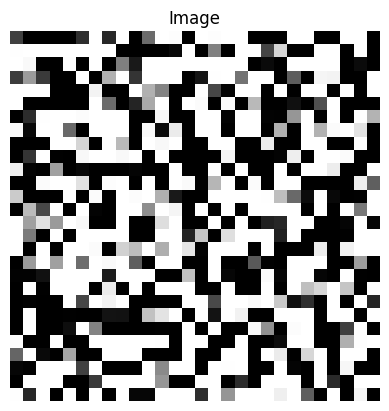

In [46]:
import matplotlib.pyplot as plt

def plot_mnist(image, title="Image"):
    plt.imshow(image.detach().numpy(), cmap='gray')
    plt.axis('off')
    plt.title(title)
    plt.show()

plot_mnist(output)

# 4. Comparison of Before and After

## 4.1 Before VAE

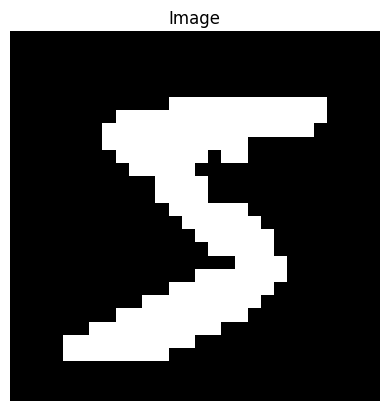

In [47]:
plot_mnist(trainData[0].reshape(train.data.shape[1], -1))

## 4.2 After VAE

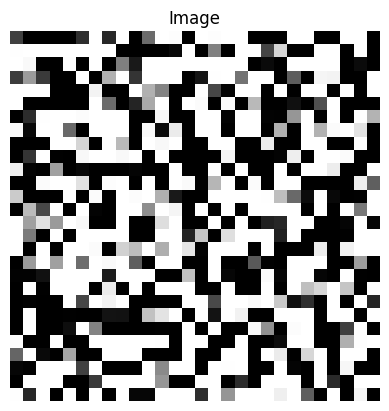

In [48]:
plot_mnist(output)

## Network hasn't learnt anything yet

# 5.Loss Calculation

In [49]:
# Whole, mean, sigma
# distParamZ, distParamZ[:J], distParamZ[J:]
meanVector = distParamZ[:J]
stdVector = distParamZ[J:]
distParamZ, meanVector, stdVector

(tensor([ 0.9981,  1.0000, -1.0000,  0.9999], grad_fn=<TanhBackward0>),
 tensor([0.9981, 1.0000], grad_fn=<SliceBackward0>),
 tensor([-1.0000,  0.9999], grad_fn=<SliceBackward0>))

In [50]:
meanVector = distParamZ[:J]
stdVector = distParamZ[J:]
KLLoss = 0.5 * (1 + torch.log(stdVector ** 2) - (meanVector ** 2) - (stdVector ** 2)).sum()
safety = 1e-4
DecoderLoss = ((trainData[0] * torch.log(decodedX + safety)) + ((1 - trainData[0]) * torch.log(1 - decodedX + safety))).sum()
elbo = KLLoss + DecoderLoss
Loss = -elbo
Loss

tensor(2972.5134, grad_fn=<NegBackward0>)

In [51]:
decodedX.shape

torch.Size([784])

In [52]:
torch.log(decodedX)

tensor([ -1.3849, -12.7644, -15.0774,  -8.9486,  -5.5668,  -1.7031,   0.0000,
         -1.8295,   0.0000, -12.5548,  -0.8634,  -0.0000,  -0.0083, -14.1215,
         -0.0000,  -0.0079,  -0.0004,   0.0000, -23.0450, -13.0574, -24.8417,
         -0.0012,  -0.0000,  -8.0619, -16.1482,  -0.0000,   0.0000, -19.0048,
         -0.0063,   0.0000,  -0.0005,  -0.0007,  -0.0000,  -0.0000,   0.0000,
         -0.0000, -12.3252,  -9.3918, -11.9264,  -9.9212,  -3.2480,  -0.0003,
         -7.8107,  -0.6855,  -7.7909,  -0.0001,   0.0000,  -1.3103,  -0.1825,
        -22.1814,  -6.4768,  -0.0001,  -0.0007, -18.3308,   0.0000, -14.8215,
         -0.0000,  -0.0261, -19.6675, -15.3110,  -0.0092, -22.7734,   0.0000,
         -7.1358,  -0.6940,  -2.2936,  -0.0028,  -0.0000,  -0.0000,   0.0000,
         -0.0000,   0.0000,   0.0000,   0.0000, -10.1839,  -3.2088, -13.0071,
          0.0000,  -0.0000,  -0.0004,   0.0000, -23.2099,  -3.1388, -21.4222,
         -1.4467,  -0.5003,  -1.4828, -24.0956, -12.8087,  -0.00

In [53]:
torch.log(1 - decodedX)

tensor([ -0.2882,  -0.0000,  -0.0000,  -0.0001,  -0.0038,  -0.2010,     -inf,
         -0.1749,     -inf,  -0.0000,  -0.5477, -14.1506,  -4.7936,  -0.0000,
        -11.8819,  -4.8450,  -7.7283,     -inf,   0.0000,  -0.0000,   0.0000,
         -6.7268, -15.9424,  -0.0003,  -0.0000, -11.6657,     -inf,   0.0000,
         -5.0638,     -inf,  -7.5979,  -7.2370, -12.4766, -13.0520,     -inf,
        -15.2492,  -0.0000,  -0.0001,  -0.0000,  -0.0000,  -0.0396,  -8.1432,
         -0.0004,  -0.7008,  -0.0004,  -9.6905,     -inf,  -0.3144,  -1.7909,
          0.0000,  -0.0015,  -9.7707,  -7.2670,   0.0000,     -inf,  -0.0000,
         -9.9484,  -3.6594,   0.0000,  -0.0000,  -4.6890,   0.0000,     -inf,
         -0.0008,  -0.6923,  -0.1064,  -5.8791, -13.5445, -10.4330,     -inf,
        -13.7452,     -inf,     -inf,     -inf,  -0.0000,  -0.0412,  -0.0000,
            -inf, -15.9424,  -7.9562,     -inf,   0.0000,  -0.0443,   0.0000,
         -0.2683,  -0.9322,  -0.2575,   0.0000,  -0.0000, -15.94

In [54]:
decodedX

tensor([0.2504, 0.0000, 0.0000, 0.0001, 0.0038, 0.1821, 1.0000, 0.1605, 1.0000,
        0.0000, 0.4217, 1.0000, 0.9917, 0.0000, 1.0000, 0.9921, 0.9996, 1.0000,
        0.0000, 0.0000, 0.0000, 0.9988, 1.0000, 0.0003, 0.0000, 1.0000, 1.0000,
        0.0000, 0.9937, 1.0000, 0.9995, 0.9993, 1.0000, 1.0000, 1.0000, 1.0000,
        0.0000, 0.0001, 0.0000, 0.0000, 0.0389, 0.9997, 0.0004, 0.5038, 0.0004,
        0.9999, 1.0000, 0.2697, 0.8332, 0.0000, 0.0015, 0.9999, 0.9993, 0.0000,
        1.0000, 0.0000, 1.0000, 0.9743, 0.0000, 0.0000, 0.9908, 0.0000, 1.0000,
        0.0008, 0.4996, 0.1009, 0.9972, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 0.0000, 0.0404, 0.0000, 1.0000, 1.0000, 0.9996, 1.0000,
        0.0000, 0.0433, 0.0000, 0.2354, 0.6063, 0.2270, 0.0000, 0.0000, 1.0000,
        0.0001, 0.6932, 1.0000, 0.2086, 1.0000, 1.0000, 1.0000, 0.0000, 0.0796,
        0.9949, 1.0000, 0.4505, 0.9961, 1.0000, 0.0000, 0.3668, 0.0004, 0.9584,
        0.9535, 0.0000, 0.0008, 1.0000, 